# ResNet-UNet Model Training

## Import Libraries and Shared Utilities

In [1]:
import sys
import os
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

from utils import (
    load_image_dataset,
    normalize,
    augment_image,
    load_dataset_with_info,
    BASE_PATH,
    IMAGE_SIZE
)

## Load and Prepare Datasets

Using shared `load_dataset_with_info` function from utils.py

In [ ]:
BATCH_SIZE = 8
IMAGE_SIZE = 224

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

tf.keras.backend.clear_session()
import gc
gc.collect()

from PIL import Image

def create_lazy_dataset(split, category, base_path, batch_size=8, image_size=224):
    full_path = Path(base_path) / split / category
    
    if not full_path.exists():
        return None, 0
    
    valid_extensions = ['.tif', '.jpg', '.png', '.jpeg', '.bmp', '.gif']
    file_paths = [str(f) for f in full_path.glob('*') if f.suffix.lower() in valid_extensions]
    file_count = len(file_paths)
    
    print(f"{split:5s}/{category:4s}: {file_count:4d} images")
    
    def image_generator():
        for file_path in file_paths:
            try:
                with Image.open(file_path) as img:
                    if category == 'Mask':
                        img = img.convert('L')
                        img = img.resize((image_size, image_size))
                        arr = np.array(img, dtype=np.float32) / 255.0
                        arr = np.expand_dims(arr, axis=-1)
                    else:
                        img = img.convert('RGB')
                        img = img.resize((image_size, image_size))
                        arr = np.array(img, dtype=np.float32) / 255.0
                    yield arr
            except Exception:
                continue
    
    if category == 'Mask':
        output_sig = tf.TensorSpec(shape=(image_size, image_size, 1), dtype=tf.float32)
    else:
        output_sig = tf.TensorSpec(shape=(image_size, image_size, 3), dtype=tf.float32)
    
    dataset = tf.data.Dataset.from_generator(image_generator, output_signature=output_sig)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=1)
    
    return dataset, file_count

print("Training Set:")
train_au_ds, train_au_count = create_lazy_dataset('train', 'Au', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
train_tp_ds, train_tp_count = create_lazy_dataset('train', 'Tp', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
train_mask_ds, train_mask_count = create_lazy_dataset('train', 'Mask', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print("\nTest Set:")
test_au_ds, _ = create_lazy_dataset('test', 'Au', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
test_tp_ds, _ = create_lazy_dataset('test', 'Tp', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
test_mask_ds, _ = create_lazy_dataset('test', 'Mask', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print("\nValidation Set:")
val_au_ds, _ = create_lazy_dataset('val', 'Au', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
val_tp_ds, _ = create_lazy_dataset('val', 'Tp', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
val_mask_ds, _ = create_lazy_dataset('val', 'Mask', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

## Normalization of images

In [ ]:
for batch in train_au_ds.take(1):
    print(f"Shape: {batch.shape}")
    print(f"Value range: [{batch.numpy().min():.3f}, {batch.numpy().max():.3f}]")

## Data Argumentation

In [ ]:
def augment_batch(images):
    images = tf.image.random_flip_left_right(images)
    images = tf.image.random_brightness(images, max_delta=0.2)
    images = tf.clip_by_value(images, 0.0, 1.0)
    images = tf.image.random_contrast(images, lower=0.8, upper=1.2)
    images = tf.clip_by_value(images, 0.0, 1.0)
    return images

train_au_ds = train_au_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
train_tp_ds = train_tp_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)

## Create Properly Paired Tp-Mask Dataset for Segmentation

The mask filename = `{tampered_filename_without_extension}_gt.png`. We need explicit filename-based pairing to ensure each tampered image is matched with its correct ground truth mask.

In [ ]:
import glob
from pathlib import Path
from PIL import Image
import numpy as np

def create_paired_tp_mask_dataset(split, base_path, batch_size=32, image_size=224):
    tp_dir = base_path / split / 'Tp'
    mask_dir = base_path / split / 'Mask'
    
    tp_files = list(tp_dir.glob('*'))
    tp_files = [f for f in tp_files if f.suffix.lower() in ['.tif', '.jpg', '.png', '.jpeg', '.bmp']]
    
    paired_tp_paths = []
    paired_mask_paths = []
    
    for tp_file in tp_files:
        tp_basename = tp_file.stem
        expected_mask_name = f"{tp_basename}_gt.png"
        mask_path = mask_dir / expected_mask_name
        
        if mask_path.exists():
            paired_tp_paths.append(str(tp_file))
            paired_mask_paths.append(str(mask_path))
    
    print(f"{split.upper()} Paired: {len(paired_tp_paths)} images")
    
    def image_generator():
        for tp_path, mask_path in zip(paired_tp_paths, paired_mask_paths):
            try:
                with Image.open(tp_path) as tp_img:
                    tp_img = tp_img.convert('RGB')
                    tp_img = tp_img.resize((image_size, image_size))
                    tp_arr = np.array(tp_img, dtype=np.float32) / 255.0
                
                with Image.open(mask_path) as mask_img:
                    mask_img = mask_img.convert('L')
                    mask_img = mask_img.resize((image_size, image_size))
                    mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
                    mask_arr = np.expand_dims(mask_arr, axis=-1)
                
                yield tp_arr, mask_arr
            except Exception:
                continue
    
    dataset = tf.data.Dataset.from_generator(
        image_generator,
        output_signature=(
            tf.TensorSpec(shape=(image_size, image_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(image_size, image_size, 1), dtype=tf.float32)
        )
    )
    
    dataset = dataset.shuffle(buffer_size=min(200, len(paired_tp_paths)))
    dataset = dataset.batch(batch_size)
    dataset = dataset.repeat()  # Repeat dataset for multiple epochs
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    steps = max(1, len(paired_tp_paths) // batch_size)
    return dataset, len(paired_tp_paths), steps

train_paired_ds, train_count, train_steps = create_paired_tp_mask_dataset('train', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
val_paired_ds, val_count, val_steps = create_paired_tp_mask_dataset('val', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
test_paired_ds, test_count, test_steps = create_paired_tp_mask_dataset('test', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print(f"\nTrain: {train_count} ({train_steps} steps) | Val: {val_count} ({val_steps} steps)")

for tp_batch, mask_batch in train_paired_ds.take(1):
    print(f"Tampered: {tp_batch.shape}, Mask: {mask_batch.shape}")

## Training ResNet-50 Classifier (Authentic vs Tampered)



In [6]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

UNFREEZE_LAYERS = 30
for layer in base_model.layers[-UNFREEZE_LAYERS:]:
    layer.trainable = True

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
frozen_count = len(base_model.layers) - trainable_count
print(f"ResNet-50: {frozen_count} frozen, {trainable_count} trainable layers")

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.4)(x)
x = Dense(1, activation='sigmoid')(x)

classifier_model = Model(inputs=base_model.input, outputs=x, name='ResNet50_Classifier')
print(f"Classifier: {classifier_model.count_params():,} params")

ResNet-50: 145 frozen, 30 trainable layers
Classifier: 24,153,473 params


##  Classification Data 

In [7]:
from PIL import Image
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def get_paths(split, category):
    path = BASE_PATH / split / category
    exts = ['.tif', '.jpg', '.png', '.jpeg', '.bmp']
    return [str(f) for f in path.glob('*') if f.suffix.lower() in exts]

train_au = get_paths('train', 'Au')
train_tp = get_paths('train', 'Tp')
val_au = get_paths('val', 'Au')
val_tp = get_paths('val', 'Tp')

print(f"Train: {len(train_au)} Au + {len(train_tp)} Tp")
print(f"Val:   {len(val_au)} Au + {len(val_tp)} Tp")

train_data = [(p, 0) for p in train_au] + [(p, 1) for p in train_tp]
val_data = [(p, 0) for p in val_au] + [(p, 1) for p in val_tp]

if not train_data or not val_data:
    raise ValueError("Training/validation data could not be loaded.")

train_labels = [l for _, l in train_data]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: Au={class_weights[0]:.3f}, Tp={class_weights[1]:.3f}")

def load_single_image(path, size):
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size, size))
        return np.array(img, dtype=np.float32) / 255.0

def _load_image_py(path):
    if isinstance(path, (bytes, np.bytes_)):
        path = path.decode('utf-8')
    elif isinstance(path, np.ndarray):
        path = path.item()
        if isinstance(path, (bytes, np.bytes_)):
            path = path.decode('utf-8')
    return load_single_image(path, IMAGE_SIZE)

def augment_image(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, 0.2)
    image = tf.image.random_contrast(image, 0.8, 1.2)
    image = tf.clip_by_value(image, 0.0, 1.0)
    return image

def build_classifier_dataset(data, batch_size, training):
    paths = [p for p, _ in data]
    labels = [l for _, l in data]
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        shuffle_buf = min(len(paths), 4096)
        dataset = dataset.shuffle(buffer_size=shuffle_buf, reshuffle_each_iteration=True)

    def _tf_parse(path, label):
        image = tf.numpy_function(func=_load_image_py, inp=[path], Tout=tf.float32)
        image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
        label = tf.cast(label, tf.float32)
        label = tf.reshape(label, [1])
        return image, label

    dataset = dataset.map(_tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
    
    if training:
        dataset = dataset.map(lambda x, y: (augment_image(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = build_classifier_dataset(train_data, BATCH_SIZE, training=True)
val_ds = build_classifier_dataset(val_data, BATCH_SIZE, training=False)

def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        pt = tf.where(tf.equal(y_true, 1), y_pred, 1 - y_pred)
        alpha_t = tf.where(tf.equal(y_true, 1), alpha, 1 - alpha)
        return -tf.reduce_mean(alpha_t * tf.pow(1 - pt, gamma) * tf.math.log(pt))
    return loss_fn

classifier_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max'),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6),
    tf.keras.callbacks.ModelCheckpoint('best_classifier.keras', monitor='val_auc', save_best_only=True, mode='max')
]

EPOCHS = 6

history_classifier = classifier_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

classifier_model.save('resnet50_classifier_tuned.keras')

Train: 1181 Au + 3151 Tp
Val:   170 Au + 445 Tp
Class weights: Au=1.834, Tp=0.687
Epoch 1/6
542/542 ━━━━━━━━━━━━━━━━━━━━ 202s 357ms/step - accuracy: 0.4806 - auc: 0.5138 - loss: 5.5056 - val_accuracy: 0.3691 - val_auc: 0.4834 - val_loss: 4.5978 - learning_rate: 1.0000e-04
Epoch 2/6
542/542 ━━━━━━━━━━━━━━━━━━━━ 190s 350ms/step - accuracy: 0.4518 - auc: 0.4776 - loss: 4.0038 - val_accuracy: 0.7187 - val_auc: 0.4746 - val_loss: 3.4311 - learning_rate: 1.0000e-04
Epoch 3/6
542/542 ━━━━━━━━━━━━━━━━━━━━ 188s 347ms/step - accuracy: 0.4504 - auc: 0.4972 - loss: 2.7960 - val_accuracy: 0.5041 - val_auc: 0.5066 - val_loss: 2.2680 - learning_rate: 1.0000e-04
Epoch 4/6
542/542 ━━━━━━━━━━━━━━━━━━━━ 183s 338ms/step - accuracy: 0.4494 - auc: 0.4961 - loss: 1.8496 - val_accuracy: 0.5610 - val_auc: 0.5158 - val_loss: 1.4532 - learning_rate: 1.0000e-04
Epoch 5/6
542/542 ━━━━━━━━━━━━━━━━━━━━ 188s 347ms/step - accuracy: 0.4321 - auc: 0.4957 - loss: 1.1550 - val_accuracy: 0.4520 - val_auc: 0.4852 - val_loss

In [9]:
version = "v2.0.0"

classifier_model.save(f"resnet50_classifier_{version}_15epochs.keras")
base_model.save(f"resnet50_encoder_{version}_15epochs.keras")


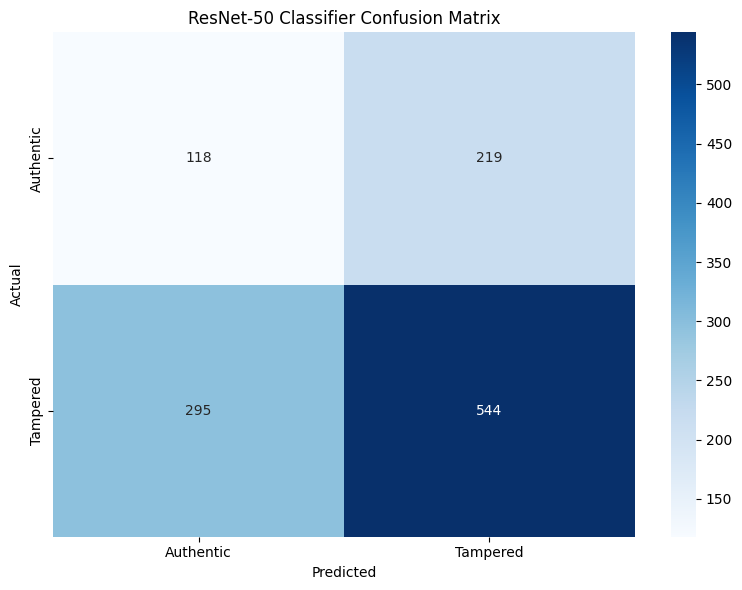

              precision    recall  f1-score   support

   Authentic       0.29      0.35      0.31       337
    Tampered       0.71      0.65      0.68       839

    accuracy                           0.56      1176
   macro avg       0.50      0.50      0.50      1176
weighted avg       0.59      0.56      0.57      1176



In [10]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

valid_exts = ['.tif', '.jpg', '.png', '.jpeg', '.bmp']
test_au = [str(f) for f in (BASE_PATH / 'test' / 'Au').glob('*') if f.suffix.lower() in valid_exts]
test_tp = [str(f) for f in (BASE_PATH / 'test' / 'Tp').glob('*') if f.suffix.lower() in valid_exts]
test_data = [(p, 0) for p in test_au] + [(p, 1) for p in test_tp]

test_ds = build_classifier_dataset(test_data, BATCH_SIZE, training=False)

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = classifier_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((preds > 0.5).astype(int).flatten())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Authentic', 'Tampered'],
            yticklabels=['Authentic', 'Tampered'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('ResNet-50 Classifier Confusion Matrix')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=['Authentic', 'Tampered']))

## UNet Decoder for Mask Prediction

In [ ]:
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Concatenate, Activation
import tensorflow.keras.backend as K

for layer in base_model.layers:
    layer.trainable = False

skip_layer_names = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out']
skip_connections = [base_model.get_layer(name).output for name in skip_layer_names]
encoder_output = base_model.output

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

def decoder_block(inputs, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Concatenate()([x, skip_features])
    x = Conv2D(num_filters, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv2D(num_filters, (3, 3), padding='same', activation='relu')(x)
    return x

x = encoder_output
x = Conv2DTranspose(512, (2, 2), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Concatenate()([x, skip_connections[3]])
x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)

x = decoder_block(x, skip_connections[2], 256)
x = decoder_block(x, skip_connections[1], 128)
x = decoder_block(x, skip_connections[0], 64)

x = Conv2DTranspose(32, (2, 2), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)

output = Conv2D(1, (1, 1), activation='sigmoid', name='mask_output')(x)

unet_model = Model(inputs=base_model.input, outputs=output, name='ResNet50_UNet')

trainable_params = sum([K.count_params(w) for w in unet_model.trainable_weights])
print(f"UNet decoder params: {trainable_params:,}")

## Train Stage 2: UNet Decoder with Mask Data

In [ ]:
if train_paired_ds is None or val_paired_ds is None:
    raise ValueError("Paired datasets not found.")

unet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=['binary_accuracy', dice_coefficient]
)

EPOCHS_STAGE2 = 12

history_stage2 = unet_model.fit(
    train_paired_ds,
    validation_data=val_paired_ds,
    epochs=EPOCHS_STAGE2,
    verbose=1
)

unet_model.save('resnet50_unet_tampering_detector.keras')

Epoch 1/12
    394/Unknown 446s 1s/step - binary_accuracy: 0.7532 - dice_coefficient: 0.1673 - loss: 1.3226

C:\Users\Paudel\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


394/394 ━━━━━━━━━━━━━━━━━━━━ 475s 1s/step - binary_accuracy: 0.8814 - dice_coefficient: 0.1112 - loss: 1.2144 - val_binary_accuracy: 0.9015 - val_dice_coefficient: 0.0970 - val_loss: 1.2182
Epoch 2/12
 11/394 ━━━━━━━━━━━━━━━━━━━━ 7:32 1s/step - binary_accuracy: 0.8884 - dice_coefficient: 0.0896 - loss: 1.2796